In [1]:
!pip install -q diffusers transformers accelerate omegaconf

In [1]:
# ══════════════════════════════════════════════════════════════════
# TEST: Dùng ĐÚNG Code B pipeline (AutoPipeline, KHÔNG ControlNet)
# + giữ crop-based + Qwen3 prompt + depth qua prompt mô tả
# ══════════════════════════════════════════════════════════════════

import torch, gc, re
from diffusers import AutoPipelineForInpainting
from diffusers.utils import load_image
from transformers import AutoTokenizer, AutoModelForCausalLM
from PIL import Image, ImageFilter
import numpy as np
import cv2

# ── Load pipeline GIỐNG Code B ───────────────────────────────────
pipe = AutoPipelineForInpainting.from_pretrained(
    "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")

pipe.load_lora_weights(
    "/content/pytorch_lora_weights.safetensors"
)
pipe.set_adapters(["default_0"], adapter_weights=[0.8])
pipe.set_progress_bar_config(disable=False)
print("✅ Pipeline ready (AutoPipeline, NO ControlNet)")

# ── Qwen3 ─────────────────────────────────────────────────────────
print("Loading Qwen3-4B...")
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B")
qwen_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-4B", torch_dtype=torch.float16, device_map="cuda",
)
print("✅ Qwen3-4B ready")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLI

✅ Pipeline ready (AutoPipeline, NO ControlNet)
Loading Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✅ Qwen3-4B ready


In [22]:
# ══════════════════════════════════════════════════════════════════
# CELL 2: Inference
# ══════════════════════════════════════════════════════════════════

def regularize_mask(mask_image, target_size, roundness_threshold=0.75, sharp=True):
    mask_np = np.array(mask_image.convert("L").resize(target_size, Image.NEAREST))
    _, binary = cv2.threshold(mask_np, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask_image.convert("L").resize(target_size, Image.NEAREST)
    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    circularity = (4 * np.pi * area / perimeter**2) if perimeter > 0 else 0
    canvas = np.zeros_like(binary)
    if circularity >= roundness_threshold:
        (cx, cy), (ma, mb), angle = cv2.fitEllipse(contour)
        if min(ma, mb) / max(ma, mb) > 0.90:
            cv2.circle(canvas, (int(cx), int(cy)), int(max(ma, mb) / 2), 255, -1)
        else:
            cv2.ellipse(canvas, (int(cx), int(cy)), (int(ma/2), int(mb/2)), angle, 0, 360, 255, -1)
    else:
        box = cv2.boxPoints(cv2.minAreaRect(contour)).astype(np.int32)
        cv2.fillPoly(canvas, [box], 255)
    return Image.fromarray(canvas)


def enhance_prompt(raw_prompt, max_clip_tokens=77):
    system = (
        "You are an expert Stable Diffusion prompt writer for interior design inpainting. "
        "As an interior design expert, please help me enhance the simple descriptions of an object into a detailed, vivid presentation of that object."
        "Given a enchance description, rewrite it into a detailed, high-quality prompt. "
        "Rules:\n1. Output ONLY the enhanced prompt\n2. Under 60 words\n"
        "3. Add: material, lighting, style, quality tags\n4. Comma-separated\n5. No quotes\n"
    )
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": f"Enhance this inpainting prompt: {raw_prompt}"},
    ]
    text = qwen_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
    )
    inputs = qwen_tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = qwen_model.generate(**inputs, max_new_tokens=120, temperature=0.7, top_p=0.9, do_sample=True)
    enhanced = qwen_tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    enhanced = re.sub(r"<\s*think\s*>.*?<\s*/\s*think\s*>", "", enhanced, flags=re.DOTALL).strip()
    enhanced = re.sub(r"<\s*think\s*>.*", "", enhanced, flags=re.DOTALL).strip()
    enhanced = re.sub(r"<[^>]+>", "", enhanced).strip().strip('"\'')
    if not enhanced:
        return raw_prompt
    clip_ids = pipe.tokenizer.encode(enhanced)
    if len(clip_ids) > max_clip_tokens:
        enhanced = pipe.tokenizer.decode(clip_ids[:max_clip_tokens], skip_special_tokens=True)
    return enhanced


def inpaint_any_resolution(pipe, init_image, mask_image, prompt, negative_prompt,
                            inpaint_size=1024, crop_padding=128, **pipe_kwargs):
    """Crop vùng mask → inpaint → paste lại (Code B logic)."""
    W, H = init_image.size
    mask_np = np.array(mask_image.convert("L"))
    ys, xs = np.where(mask_np > 127)
    if len(xs) == 0:
        raise ValueError("Mask trống")

    x1 = max(0, xs.min() - crop_padding)
    y1 = max(0, ys.min() - crop_padding)
    x2 = min(W, xs.max() + crop_padding)
    y2 = min(H, ys.max() + crop_padding)

    print(f"  Ảnh gốc : {W}×{H}")
    print(f"  Crop    : ({x1},{y1})→({x2},{y2}) [{x2-x1}×{y2-y1}]")

    crop_img  = init_image.convert("RGB").crop((x1, y1, x2, y2))
    crop_mask = mask_image.convert("L").crop((x1, y1, x2, y2))
    crop_w, crop_h = crop_img.size

    scale = inpaint_size / max(crop_w, crop_h)
    inp_w = (int(crop_w * scale) // 64) * 64
    inp_h = (int(crop_h * scale) // 64) * 64

    inp_img  = crop_img.resize((inp_w, inp_h), Image.LANCZOS)
    inp_mask = crop_mask.resize((inp_w, inp_h), Image.NEAREST)

    print(f"  Inpaint : {inp_w}×{inp_h}")

    result_small = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=inp_img,
        mask_image=inp_mask,
        **pipe_kwargs,
    ).images[0]

    result_crop = result_small.resize((crop_w, crop_h), Image.LANCZOS)
    output = init_image.convert("RGB").copy()
    output.paste(result_crop, (x1, y1), mask=crop_mask.resize((crop_w, crop_h), Image.NEAREST))
    return output

Ảnh gốc: 717×1024
  Ảnh gốc : 717×1024
  Crop    : (73,267)→(423,603) [350×336]
  Inpaint : 1024×960


  0%|          | 0/47 [00:00<?, ?it/s]

🚀 Đang thực hiện Poisson Blending...


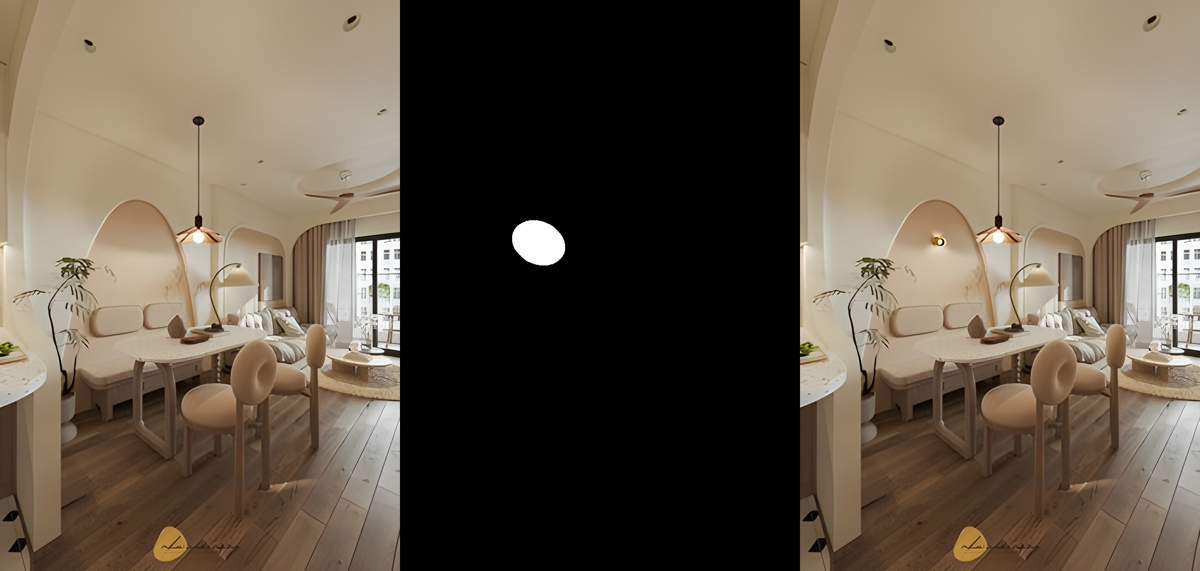

✅ Đã lưu kết quả Poisson Blending!
round metal wall lamp, polished brass finish, soft ambient lighting, modern minimalistic style, high detail, realistic render, 4K resolution, interior design, elegant lighting, contemporary home decor


In [24]:
# ── Run ───────────────────────────────────────────────────────────
init_image = load_image("52.png").convert("RGB")
W, H = init_image.size
print(f"Ảnh gốc: {W}×{H}")

mask_image = regularize_mask(load_image("mask_test.png"), target_size=(W, H))

raw_prompt = "A round metal wall lamp"
prompt = enhance_prompt(raw_prompt)
negative_prompt = "low quality, blurry, distorted, deformed, floating, abstract, cartoon, artifacts"

torch.cuda.empty_cache(); gc.collect()

# Inpaint lấy kết quả thô
result_raw = inpaint_any_resolution(
    pipe, init_image, mask_image,
    prompt=prompt,
    negative_prompt=negative_prompt,
    inpaint_size=1024,
    crop_padding=128,
    strength=0.95,
    num_inference_steps=50,
    guidance_scale=8.0,
    generator=torch.Generator("cuda").manual_seed(42),
)

# ── Poisson Seamless Blend (Thay thế Feather Blend) ─────────────────
print("🚀 Đang thực hiện Poisson Blending...")

# 1. Chuyển đổi sang định dạng OpenCV (BGR)
dst = cv2.cvtColor(np.array(init_image), cv2.COLOR_RGB2BGR) # Ảnh nền gốc
src = cv2.cvtColor(np.array(result_raw), cv2.COLOR_RGB2BGR) # Ảnh sau inpaint
mask = np.array(mask_image.convert("L")) # Mask trắng đen

# 2. Tìm Bounding Box của mask để xác định vùng trung tâm
# Poisson Clone cần một điểm trung tâm (center) để đặt vùng ảnh nguồn vào ảnh đích
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    # Lấy bounding box của vùng mask lớn nhất
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    center = (x + w // 2, y + h // 2)

    # 3. Thực hiện Seamless Clone
    # cv2.NORMAL_CLONE: Giữ nguyên chi tiết vật thể, thay đổi màu sắc cho khớp nền.
    # cv2.MIXED_CLONE: Pha trộn cả texture của nền (dùng nếu muốn nhìn xuyên qua hoặc hòa quyện mạnh)
    try:
        blended_cv = cv2.seamlessClone(src, dst, mask, center, cv2.NORMAL_CLONE)
        result = Image.fromarray(cv2.cvtColor(blended_cv, cv2.COLOR_BGR2RGB))
    except Exception as e:
        print(f"⚠️ Poisson Blend lỗi: {e}. Quay lại dùng ảnh inpaint gốc.")
        result = result_raw
else:
    print("⚠️ Không tìm thấy mask hợp lệ để Poisson Blend.")
    result = result_raw

# ── Display ───────────────────────────────────────────────────────
result.save("result_poisson.png")
combined = Image.new("RGB", (W * 3, H))
combined.paste(init_image,               (0,     0))
combined.paste(mask_image.convert("RGB"), (W,     0))
combined.paste(result,                   (W * 2, 0))

display(combined.resize((1200, int(1200 * H / (W * 3)))))
print(f"✅ Đã lưu kết quả Poisson Blending!")
print(prompt)